<a href="https://colab.research.google.com/github/jiminAn/2023_SUMMER_SAMSUNG_DL/blob/main/%EC%8B%A4%EC%8A%B5%EC%9E%90%EB%A3%8C/Day5/Day_5_3_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 5.3 Transformer
### 실습 목표
- Transformer를 구현해보자.


Reference: https://www.youtube.com/watch?v=M6adRGJe5cQ&t=180s

In [1]:
import torch
torch.cuda.is_available()

True

In [6]:
!pip install -U torchtext==0.6.0
!pip install tensorboard
!pip install spacy

  Using cached torchtext-0.6.0-py3-none-any.whl.metadata (6.3 kB)
Using cached torchtext-0.6.0-py3-none-any.whl (64 kB)
  Attempting uninstall: torchtext
    Found existing installation: torchtext 0.18.0
    Uninstalling torchtext-0.18.0:
      Successfully uninstalled torchtext-0.18.0


In [20]:
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 98.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import sys

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torchtext.data.metrics import bleu_score
from torchtext.datasets import Multi30k
# from torchtext.data import Field, BucketIterator
from torchtext.data import Field, BucketIterator
import spacy

![](https://pytorch.org/tutorials/_images/transformer_architecture.jpg)

Transformer block 구조

In [12]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, dropout=0.1):
        super(TransformerBlock, self).__init__()
        # Multi-Head Self-Attention
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)

        # Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Linear(ff_hidden_dim, embed_dim)
        )

        # Layer Normalization
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-Attention
        attn_output, _ = self.attention(x, x, x, attn_mask=mask) #self attention이기 때문에, query, key, value의 계산이 하나의 sequence 내에서 일어남
        x = x + self.dropout(attn_output)  # Residual connection
        x = self.norm1(x)  # Layer Normalization

        # Feed-Forward Network
        ffn_output = self.ffn(x)
        x = x + self.dropout(ffn_output)  # Residual connection
        x = self.norm2(x)  # Layer Normalization

        return x

In [7]:
transformerblock = TransformerBlock(embed_dim=512,  num_heads=8, ff_hidden_dim=2048)

In [8]:
print(transformerblock)

TransformerBlock(
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (ffn): Sequential(
    (0): Linear(in_features=512, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=512, bias=True)
  )
  (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


In [9]:
transformer = nn.Transformer(
    d_model=512,
    nhead=8,
    num_encoder_layers=1,
    num_decoder_layers=1,
    dim_feedforward=2048,
    dropout=0.1
)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [10]:
print(transformer.encoder.layers)

ModuleList(
  (0): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
    (linear1): Linear(in_features=512, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=512, bias=True)
    (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
)


In [15]:
def translate_sentence(model, sentence, german, english, device, max_length=50):
    # Load german tokenizer
    # spacy_ger = spacy.load("de")
    spacy_ger = spacy.load("de_core_news_sm")

    # Create tokens using spacy and everything in lower case (which is what our vocab is)
    if type(sentence) == str:
        tokens = [token.text.lower() for token in spacy_ger(sentence)]
    else:
        tokens = [token.lower() for token in sentence]

    # Add <SOS> and <EOS> in beginning and end respectively
    tokens.insert(0, german.init_token)
    tokens.append(german.eos_token)

    # Go through each german token and convert to an index
    text_to_indices = [german.vocab.stoi[token] for token in tokens]

    # Convert to Tensor
    sentence_tensor = torch.LongTensor(text_to_indices).unsqueeze(1).to(device)

    outputs = [english.vocab.stoi["<sos>"]]
    for i in range(max_length):
        trg_tensor = torch.LongTensor(outputs).unsqueeze(1).to(device)

        with torch.no_grad():
            output = model(sentence_tensor, trg_tensor)

        best_guess = output.argmax(2)[-1, :].item()
        outputs.append(best_guess)

        if best_guess == english.vocab.stoi["<eos>"]:
            break

    translated_sentence = [english.vocab.itos[idx] for idx in outputs]
    # remove start token
    return translated_sentence[1:]


def bleu(data, model, german, english, device):
    targets = []
    outputs = []

    for example in data:
        src = vars(example)["src"]
        trg = vars(example)["trg"]

        prediction = translate_sentence(model, src, german, english, device)
        prediction = prediction[:-1]  # remove <eos> token

        targets.append([trg])
        outputs.append(prediction)

    return bleu_score(outputs, targets)


def save_checkpoint(state, filename="my_checkpoint.pth.tar"):
    print("=> Saving checkpoint")
    torch.save(state, filename)


def load_checkpoint(checkpoint, model, optimizer):
    print("=> Loading checkpoint")
    model.load_state_dict(checkpoint["state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer"])

In [8]:
# spacy_ger = spacy.load("de")
# spacy_eng = spacy.load("en")
spacy_ger = spacy.load("de_core_news_sm")
spacy_eng = spacy.load("en_core_web_sm")


def tokenize_ger(text):
    return [tok.text for tok in spacy_ger.tokenizer(text)]

def tokenize_eng(text):
    return [tok.text for tok in spacy_eng.tokenizer(text)]


german = Field(tokenize=tokenize_ger, lower=True, init_token="<sos>", eos_token="<eos>")

english = Field(
    tokenize=tokenize_eng, lower=True, init_token="<sos>", eos_token="<eos>"
)

train_data, valid_data, test_data = Multi30k.splits(
    exts=(".de", ".en"), fields=(german, english)
)


german.build_vocab(train_data, max_size=10000, min_freq=2)
english.build_vocab(train_data, max_size=10000, min_freq=2)


class Transformer(nn.Module):
    def __init__(
        self,
        embedding_size,
        src_vocab_size,
        trg_vocab_size,
        src_pad_idx,
        num_heads,
        num_encoder_layers,
        num_decoder_layers,
        forward_expansion,
        dropout,
        max_len,
        device,
    ):
        super(Transformer, self).__init__()
        self.src_word_embedding = nn.Embedding(src_vocab_size, embedding_size)
        self.src_position_embedding = nn.Embedding(max_len, embedding_size)
        self.trg_word_embedding = nn.Embedding(trg_vocab_size, embedding_size)
        self.trg_position_embedding = nn.Embedding(max_len, embedding_size)

        self.device = device
        self.transformer = nn.Transformer(
            embedding_size,
            num_heads,
            num_encoder_layers,
            num_decoder_layers,
            forward_expansion,
            dropout,
        )
        self.fc_out = nn.Linear(embedding_size, trg_vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.src_pad_idx = src_pad_idx

    def make_src_mask(self, src):
        src_mask = src.transpose(0, 1) == self.src_pad_idx

        # (N, src_len)
        return src_mask.to(self.device)

    def forward(self, src, trg):
        src_seq_length, N = src.shape
        trg_seq_length, N = trg.shape

        src_positions = (
            torch.arange(0, src_seq_length)
            .unsqueeze(1)
            .expand(src_seq_length, N)
            .to(self.device)
        )

        trg_positions = (
            torch.arange(0, trg_seq_length)
            .unsqueeze(1)
            .expand(trg_seq_length, N)
            .to(self.device)
        )

        embed_src = self.dropout(
            (self.src_word_embedding(src) + self.src_position_embedding(src_positions))
        )
        embed_trg = self.dropout(
            (self.trg_word_embedding(trg) + self.trg_position_embedding(trg_positions))
        )

        src_padding_mask = self.make_src_mask(src)
        trg_mask = self.transformer.generate_square_subsequent_mask(trg_seq_length).to(
            self.device
        )

        out = self.transformer(
            embed_src,
            embed_trg,
            src_key_padding_mask=src_padding_mask,
            tgt_mask=trg_mask,
        )
        out = self.fc_out(out)
        return out


# We're ready to define everything we need for training our Seq2Seq model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

load_model = True
save_model = True

# Training hyperparameters
num_epochs = 10
learning_rate = 3e-4
batch_size = 32

# Model hyperparameters
src_vocab_size = len(german.vocab)
trg_vocab_size = len(english.vocab)
embedding_size = 512
num_heads = 8
num_encoder_layers = 3
num_decoder_layers = 3
dropout = 0.10
max_len = 100
forward_expansion = 4
src_pad_idx = english.vocab.stoi["<pad>"]

# Tensorboard to get nice loss plot
writer = SummaryWriter("runs/loss_plot")
step = 0

FileNotFoundError: [Errno 2] No such file or directory: '.data/multi30k/train.de'

In [ ]:
train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size=batch_size,
    sort_within_batch=True,
    sort_key=lambda x: len(x.src),
    device=device,
)

In [ ]:
model = Transformer(
    embedding_size,
    src_vocab_size,
    trg_vocab_size,
    src_pad_idx,
    num_heads,
    num_encoder_layers,
    num_decoder_layers,
    forward_expansion,
    dropout,
    max_len,
    device,
).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.1, patience=10, verbose=True
)

pad_idx = english.vocab.stoi["<pad>"]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

In [ ]:
# if load_model:
#     load_checkpoint(torch.load("my_checkpoint.pth.tar"), model, optimizer)

sentence = "ein pferd geht unter einer brücke neben einem boot."
# -> english: A horse walks under a bridge next to a boat.
num_epochs = 20
for epoch in range(10, num_epochs):
    print(f"[Epoch {epoch} / {num_epochs}]")

    if save_model:
        checkpoint = {
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
        }
        save_checkpoint(checkpoint)

    model.eval()
    translated_sentence = translate_sentence(
        model, sentence, german, english, device, max_length=50
    )

    print(f"Translated example sentence: \n {translated_sentence}")
    model.train()
    losses = []

    for batch_idx, batch in enumerate(train_iterator):
        # Get input and targets and get to cuda
        inp_data = batch.src.to(device)
        target = batch.trg.to(device)

        # Forward prop
        output = model(inp_data, target[:-1, :])

        output = output.reshape(-1, output.shape[2])
        target = target[1:].reshape(-1)

        optimizer.zero_grad()

        loss = criterion(output, target)
        losses.append(loss.item())

        # Back prop
        loss.backward()

        # Clip to avoid exploding gradient issues, makes sure grads are
        # within a healthy range
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        # Gradient descent step
        optimizer.step()

        # plot to tensorboard
        writer.add_scalar("Training loss", loss, global_step=step)
        step += 1

    mean_loss = sum(losses) / len(losses)
    scheduler.step(mean_loss)

# running on entire test data takes a while
score = bleu(test_data[1:100], model, german, english, device)
print(f"Bleu score {score * 100:.2f}")

[Epoch 10 / 20]
=> Saving checkpoint
Translated example sentence: 
 ['overturned', 'prepare', 'say', 'say', 'balloon', 'prepare', 'say', 'say', 'its', 'overturned', 'mound', 'overturned', 'oversized', 'its', 'overturned', 'say', 'say', 'print', 'overturned', 'its', 'trying', 'say', 'snowboard', 'view', 'shots', 'busily', 'beam', 'its', 'prepare', 'its', 'view', 'trying', 'print', 'view', 'print', 'trying', 'holding', 'trying', 'latin', 'overturned', 'beam', 'speed', 'bagpipes', 'say', 'say', 'engages', 'print', 'trying', 'its', 'overturned']
[Epoch 11 / 20]
=> Saving checkpoint
Translated example sentence: 
 ['a', 'horse', 'walks', 'under', 'a', 'bridge', 'next', 'to', 'a', 'boat', '.', '<eos>']
[Epoch 12 / 20]
=> Saving checkpoint
Translated example sentence: 
 ['a', 'horse', 'walks', 'under', 'a', 'bridge', 'next', 'to', 'a', 'boat', '.', '<eos>']
[Epoch 13 / 20]
=> Saving checkpoint
Translated example sentence: 
 ['a', 'horse', 'walks', 'under', 'a', 'bridge', 'under', 'a', 'boat', 

In [ ]:
model.eval()
sentence = "Ich gehe zur Schule." # -> english: I go to school.
translated_sentence = translate_sentence(model, sentence, german, english, device, max_length=50)
print(translated_sentence)

['i', 'am', 'the', 'school', '.', '<eos>']


GPT 구현하기
 - Generative Pre-trained Transformer
 - 문장을 생성하는 모델
 - GPT는 Transformer의 decoder 부분만 이용한 모델
 - Encoder를 사용 안하기 때문에, encoder와의 attention 계산하는 레이어가 존재하지 않음

 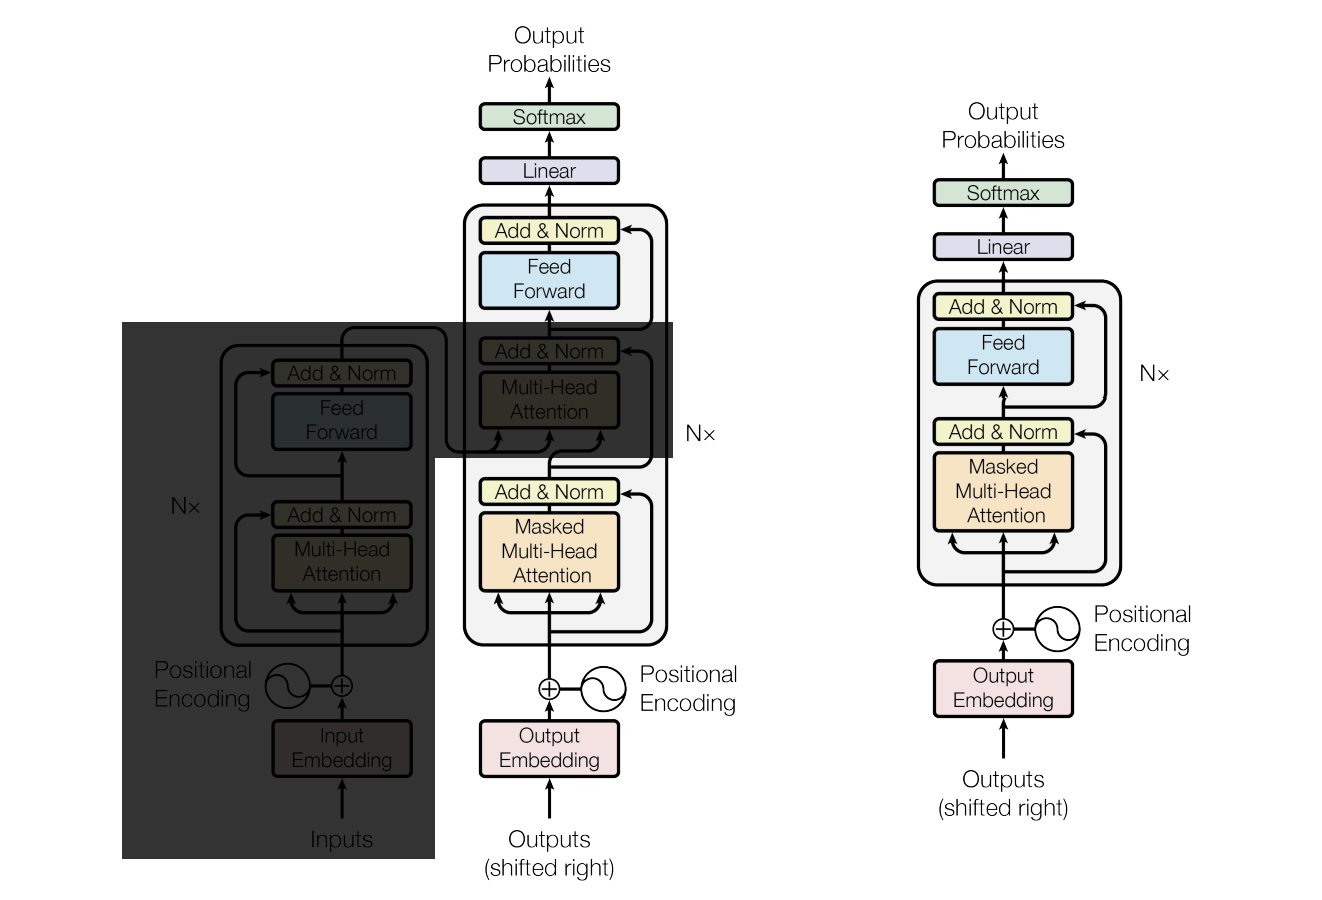


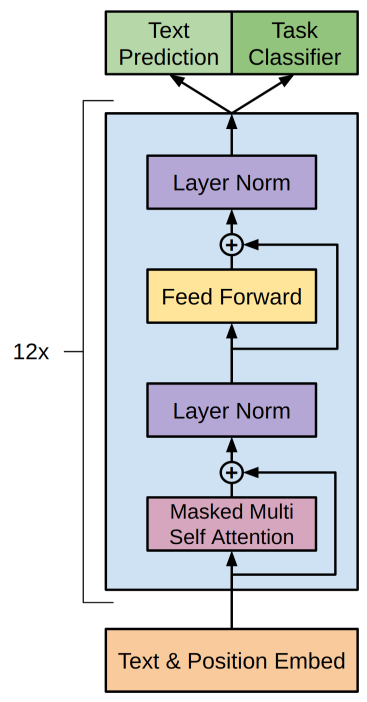




In [ ]:
class GPTBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super(GPTBlock, self).__init__()

        ################## complete code from here ####################

        ################## complete code to here ####################

    def forward(self, x, mask):
        ################## complete code from here ####################

        ################## complete code to here ####################
        return x

Next word Prediction
- GPT가 문장을 생성하는 원리
- 현재까지 주어진 단어를 보고, 그 다음에 올 단어를 예측
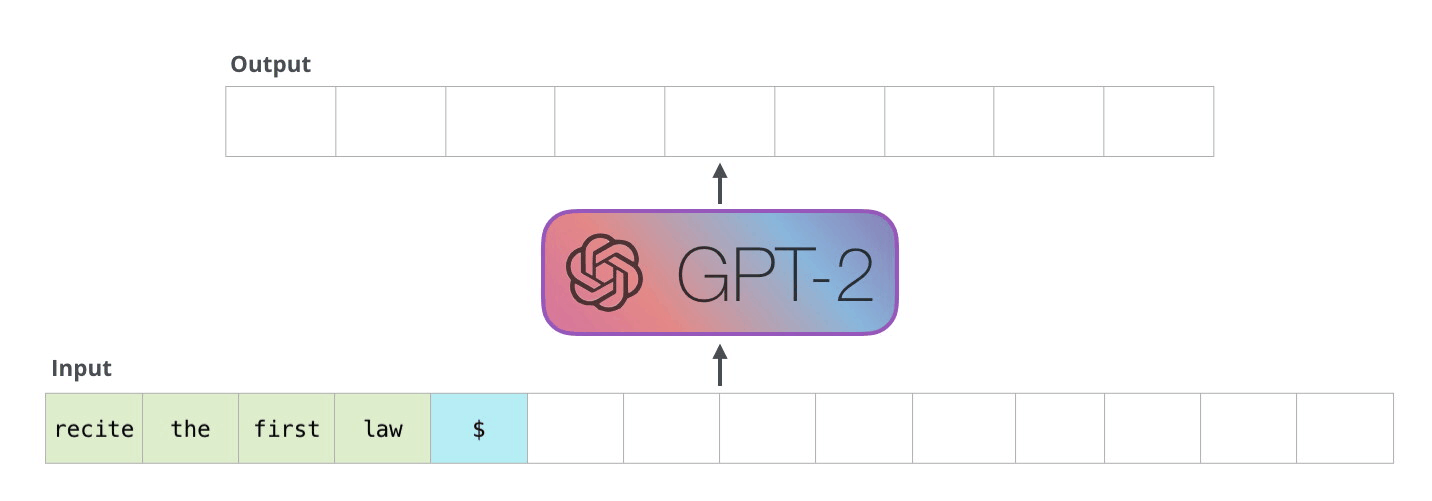

Pretraining vs Fine Tuning
- 학습은 총 두단계로 이루어짐
- Pretraining: 언어에 대해서 배우는 단계. 다량의 데이터 및 학습시간 요구
- Finetuning: pretraining된 언어지식을 바탕으로 Task(번역, 요약, 분류 등)에 대해서 보다 좁게 학습하는 단계.
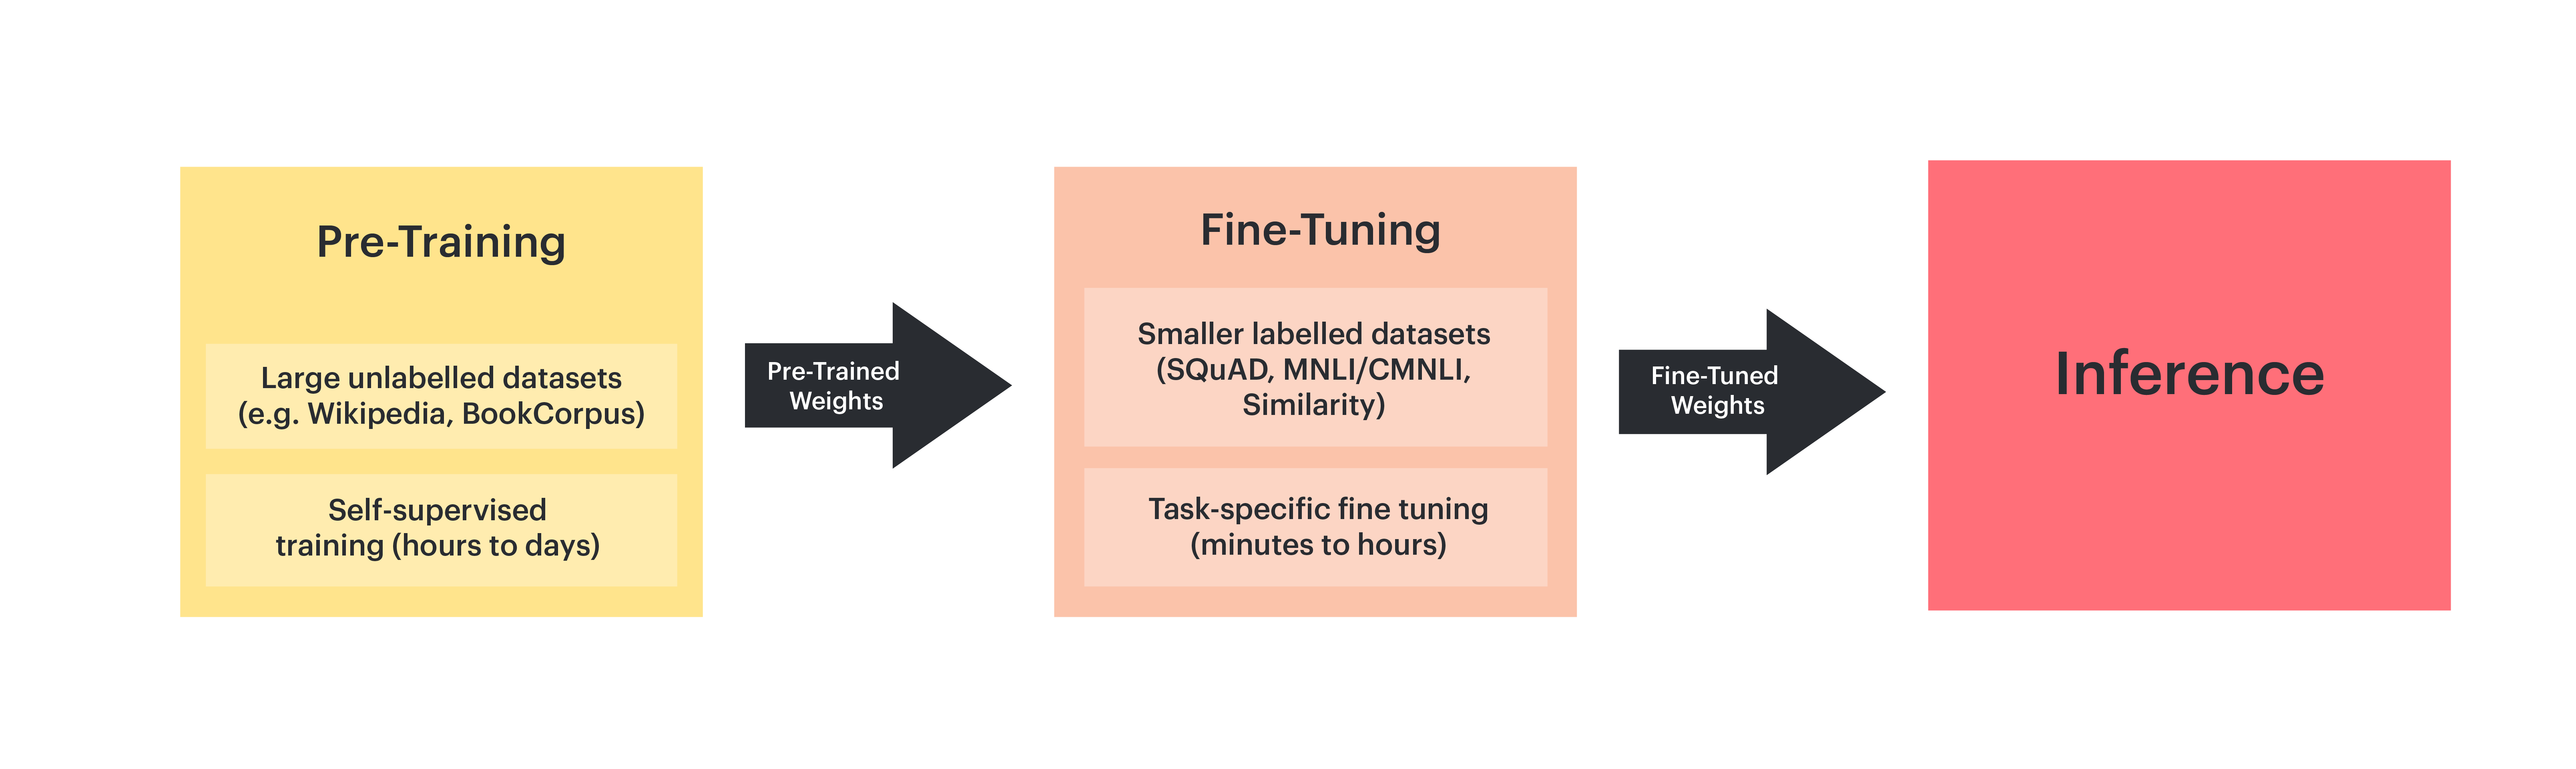

예시) "안녕하세요?"라는 입력이 주어졌을 때.
- Pretrain만 된 GPT: "안녕하세요?" 는 한국에서 다른 사람과 만났을때 하는 인사말로, 한국에서 가장 보편적인 인사말이다. ~~~
- Fine-Tuning 이후 : "안녕하세요?" "네 안녕하세요"